# Three representations of a Fokker--Planck gradient flow

This notebook generates `fig:gradflow-fokker-planck-three-representations`.  The target density $\beta$ is a two-component Gaussian mixture shifted to the right of an initially isotropic Gaussian law.  We compare three numerical pictures of the same entropy-regularized Wasserstein gradient flow

$$
\partial_t \rho_t = \tau\,\Delta\rho_t - \tau\,\nabla\cdot(\rho_t\nabla\log\beta),
$$

namely independent Langevin trajectories, deterministic particles driven by the KDE approximation of $\nabla\log\rho_t$, and a grid Fokker--Planck solver.  The displayed times are deliberately front-loaded to show the beginning of the deformation before the density becomes visibly bimodal.


## Parameters and target score

The score of the target mixture is available in closed form, which avoids any numerical ambiguity in the drift shared by the three rows.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter, map_coordinates

HERE = Path.cwd().resolve()
ROOT = HERE if (HERE / "notebooks-figures").exists() else HERE.parents[0]
if str(ROOT / "notebooks-figures") not in sys.path:
    sys.path.append(str(ROOT / "notebooks-figures"))
from figure_style import setup_matplotlib, figure_dir, save_pdf, remove_axes, interp_color

setup_matplotlib()
name = "gradflow-fokker-planck-three-representations"
out_dir = figure_dir(name)
thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(exist_ok=True)

# The same target-score flow is used for all three rows.
rng_sde = np.random.default_rng(20260614)
rng_kde = np.random.default_rng(20260615)
weights = np.array([0.50, 0.50])
means = np.array([[0.30, -0.22], [0.78, 0.25]])
Sigmas = np.array([
    [[0.21**2, 0.008], [0.008, 0.17**2]],
    [[0.22**2, -0.008], [-0.008, 0.17**2]],
])
invS = np.linalg.inv(Sigmas)
dets = np.linalg.det(Sigmas)

xlim = (-1.06, 1.28)
ylim = (-0.82, 0.82)
init_mean = np.array([-0.52, 0.02])
init_std = 0.24

# Front-loaded display times: the early deformation is the point of the figure.
tau = 0.10
T = 2.40
steps = 1600
dt = T / steps
snapshot_times = np.array([0.06, 0.16, 0.55, T])
snapshot_ids = np.round(snapshot_times / dt).astype(int)
snapshot_ids[-1] = steps
snapshot_by_id = dict(zip(snapshot_ids, snapshot_times))
path_stride = 8
path_times = np.arange(0, steps + 1, path_stride) * dt

ng_plot = 220
grid_x = np.linspace(*xlim, ng_plot)
grid_y = np.linspace(*ylim, ng_plot)
XX, YY = np.meshgrid(grid_x, grid_y)
GRID = np.stack([XX, YY], axis=-1)

def beta_density(X):
    X = np.asarray(X)
    vals = np.zeros(X.shape[:-1])
    for w, m, S_inv, det in zip(weights, means, invS, dets):
        d = X - m
        q = np.einsum("...i,ij,...j->...", d, S_inv, d)
        vals += w * np.exp(-0.5 * q) / (2 * np.pi * np.sqrt(det))
    return vals

def score_beta(X):
    X = np.asarray(X)
    num = np.zeros_like(X, dtype=float)
    den = np.zeros(X.shape[:-1], dtype=float)
    for w, m, S_inv, det in zip(weights, means, invS, dets):
        d = X - m
        q = np.einsum("...i,ij,...j->...", d, S_inv, d)
        comp = w * np.exp(-0.5 * q) / (2 * np.pi * np.sqrt(det))
        den += comp
        num += comp[..., None] * (-(d @ S_inv.T))
    return num / np.maximum(den[..., None], 1e-300)

Zbeta = beta_density(GRID)
target_levels = np.linspace(np.quantile(Zbeta, 0.74), np.quantile(Zbeta, 0.975), 5)

def clip_velocity(V, vmax=1.45):
    speed = np.linalg.norm(V, axis=-1, keepdims=True)
    return V * np.minimum(1.0, vmax / np.maximum(speed, 1e-12))


## Three numerical representations

The Langevin row follows the stochastic particle system.  The deterministic row replaces the density score by a grid-KDE estimate of $\nabla\log\rho_t$; it uses many particles and a smaller smoothing bandwidth, while only a subset of trajectories is displayed.  The grid row uses a conservative push-forward/diffusion splitting for the Fokker--Planck equation.


In [2]:
# 1) Independent Langevin particles: dX_t = tau grad log beta(X_t) dt + sqrt(2 tau) dB_t.
def simulate_sde(n=3200, n_paths=58):
    X = init_mean + init_std * rng_sde.normal(size=(n, 2))
    path_idx = rng_sde.choice(n, size=n_paths, replace=False)
    paths = [X[path_idx].copy()]
    snapshots = {}
    ids = set(snapshot_ids)
    for k in range(1, steps + 1):
        V = clip_velocity(tau * score_beta(X), vmax=1.55)
        X = X + dt * V + np.sqrt(2 * tau * dt) * rng_sde.normal(size=X.shape)
        X[:, 0] = np.clip(X[:, 0], xlim[0] + 0.005, xlim[1] - 0.005)
        X[:, 1] = np.clip(X[:, 1], ylim[0] + 0.005, ylim[1] - 0.005)
        if k % path_stride == 0:
            paths.append(X[path_idx].copy())
        if k in ids:
            snapshots[k] = X.copy()
    return snapshots, np.stack(paths, axis=1)

# 2) Deterministic particles using a grid-smoothed KDE score for rho_t.
# A large particle set permits a sharper KDE score; only a small trajectory subset is displayed.
kde_particle_count = 5200
kde_path_count = 48
kde_path_candidates = 192
kde_bandwidth = 0.10
score_nx, score_ny = 146, 102
score_xs = np.linspace(*xlim, score_nx)
score_ys = np.linspace(*ylim, score_ny)
score_dx = score_xs[1] - score_xs[0]
score_dy = score_ys[1] - score_ys[0]
score_edges_x = np.linspace(xlim[0] - 0.5 * score_dx, xlim[1] + 0.5 * score_dx, score_nx + 1)
score_edges_y = np.linspace(ylim[0] - 0.5 * score_dy, ylim[1] + 0.5 * score_dy, score_ny + 1)

def grid_kde_score(points, bandwidth=kde_bandwidth):
    hist, _, _ = np.histogram2d(points[:, 0], points[:, 1], bins=[score_edges_x, score_edges_y])
    rho = gaussian_filter(hist.T, sigma=(bandwidth / score_dy, bandwidth / score_dx), mode="nearest")
    rho = rho + 1e-7 * max(float(rho.max()), 1.0)
    log_rho = np.log(rho)
    grad_y, grad_x = np.gradient(log_rho, score_dy, score_dx, edge_order=2)
    coords_x = (points[:, 0] - score_xs[0]) / score_dx
    coords_y = (points[:, 1] - score_ys[0]) / score_dy
    coords = np.vstack([coords_y, coords_x])
    sx = map_coordinates(grad_x, coords, order=1, mode="nearest")
    sy = map_coordinates(grad_y, coords, order=1, mode="nearest")
    score = np.column_stack([sx, sy])
    return clip_velocity(score, vmax=8.5)

def select_balanced_paths(paths, n_keep):
    final = paths[:, -1, :]
    assignment = np.argmin(np.sum((final[:, None, :] - means[None, :, :]) ** 2, axis=2), axis=1)
    keep = []
    quotas = [n_keep // 2, n_keep - n_keep // 2]
    for comp, quota in enumerate(quotas):
        pool = np.flatnonzero(assignment == comp)
        if len(pool) == 0:
            continue
        chosen = pool if len(pool) <= quota else rng_kde.choice(pool, size=quota, replace=False)
        keep.extend(chosen.tolist())
    if len(keep) < n_keep:
        rest = np.setdiff1d(np.arange(len(paths)), np.asarray(keep, dtype=int), assume_unique=False)
        fill = rng_kde.choice(rest, size=min(n_keep - len(keep), len(rest)), replace=False)
        keep.extend(fill.tolist())
    keep = np.asarray(keep[:n_keep], dtype=int)
    rng_kde.shuffle(keep)
    return paths[keep]

def simulate_kde_particles(n=kde_particle_count, n_paths=kde_path_count, n_path_candidates=kde_path_candidates):
    X = init_mean + init_std * rng_kde.normal(size=(n, 2))
    path_idx = rng_kde.choice(n, size=n_path_candidates, replace=False)
    paths = [X[path_idx].copy()]
    snapshots = {}
    ids = set(snapshot_ids)
    for k in range(1, steps + 1):
        score_rho = grid_kde_score(X)
        V = clip_velocity(tau * (score_beta(X) - score_rho), vmax=1.35)
        X = X + dt * V
        X[:, 0] = np.clip(X[:, 0], xlim[0] + 0.005, xlim[1] - 0.005)
        X[:, 1] = np.clip(X[:, 1], ylim[0] + 0.005, ylim[1] - 0.005)
        if k % path_stride == 0:
            paths.append(X[path_idx].copy())
        if k in ids:
            snapshots[k] = X.copy()
    return snapshots, select_balanced_paths(np.stack(paths, axis=1), n_paths)

# 3) Grid Fokker--Planck solver: conservative push-forward by the drift, followed by heat diffusion.
def simulate_grid_pde(nx=170, ny=118):
    xs = np.linspace(*xlim, nx)
    ys = np.linspace(*ylim, ny)
    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]
    Xg, Yg = np.meshgrid(xs, ys)
    G = np.stack([Xg, Yg], axis=-1)
    drift = clip_velocity(tau * score_beta(G), vmax=1.55)
    rho = np.exp(-0.5 * np.sum((G - init_mean) ** 2, axis=-1) / init_std**2) / (2 * np.pi * init_std**2)
    rho /= rho.sum()
    snapshots = {0: rho.copy()}
    ids = set(snapshot_ids)
    sigma_pix = (np.sqrt(2 * tau * dt) / dy, np.sqrt(2 * tau * dt) / dx)
    for k in range(1, steps + 1):
        Xd = Xg + dt * drift[..., 0]
        Yd = Yg + dt * drift[..., 1]
        fx = (Xd - xs[0]) / dx
        fy = (Yd - ys[0]) / dy
        i0 = np.floor(fx).astype(int)
        j0 = np.floor(fy).astype(int)
        wx = np.clip(fx - i0, 0, 1)
        wy = np.clip(fy - j0, 0, 1)
        i0 = np.clip(i0, 0, nx - 2)
        j0 = np.clip(j0, 0, ny - 2)
        new = np.zeros_like(rho)
        np.add.at(new, (j0, i0), rho * (1 - wx) * (1 - wy))
        np.add.at(new, (j0, i0 + 1), rho * wx * (1 - wy))
        np.add.at(new, (j0 + 1, i0), rho * (1 - wx) * wy)
        np.add.at(new, (j0 + 1, i0 + 1), rho * wx * wy)
        rho = gaussian_filter(new, sigma=sigma_pix, mode="nearest")
        rho = np.maximum(rho, 0)
        rho /= np.maximum(rho.sum(), 1e-15)
        if k in ids:
            snapshots[k] = rho.copy()
    return xs, ys, snapshots

snap_sde, paths_sde = simulate_sde()
snap_kde, paths_kde = simulate_kde_particles()
xs_pde, ys_pde, snap_pde = simulate_grid_pde()


## Export

The first column of the two particle rows displays a subsample of trajectories.  The following columns use early-time snapshots and a longer final time; the density row uses the same time grid, with the initial density shown in the first column.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


...

'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


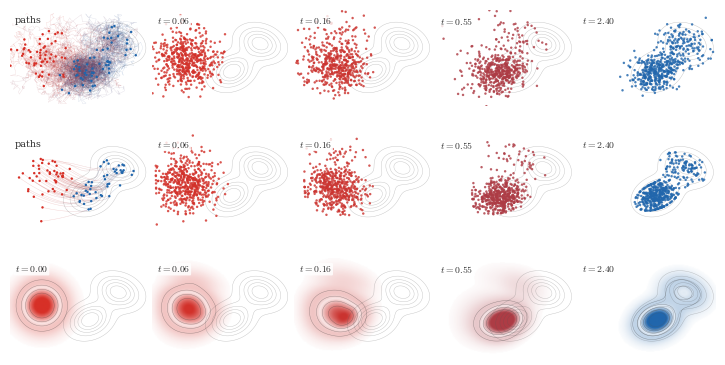

In [3]:
# Rendering utilities: no embedded titles, only time/path annotations inside panels.
def make_time_cmap(t):
    c = interp_color(float(t))
    return LinearSegmentedColormap.from_list("time", [(1, 1, 1, 1), (*c, 0.12), (*c, 1.0)])

def draw_target_contours(ax):
    ax.contour(XX, YY, Zbeta, levels=target_levels, colors="#555555", linewidths=0.32, alpha=0.34)

def panel_label(ax, text):
    ax.text(
        0.035,
        0.94,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7,
        color="#333333",
        bbox=dict(boxstyle="round,pad=0.12", facecolor="white", edgecolor="none", alpha=0.82),
    )

def format_ax(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)

def draw_paths(ax, paths, alpha=0.18):
    draw_target_contours(ax)
    n_path, n_time, _ = paths.shape
    segments, colors = [], []
    for p in paths:
        for k in range(n_time - 1):
            segments.append([p[k], p[k + 1]])
            colors.append((*interp_color(k / max(n_time - 2, 1)), alpha))
    lc = LineCollection(segments, colors=colors, linewidths=0.32, zorder=1)
    ax.add_collection(lc)
    ax.scatter(paths[:, 0, 0], paths[:, 0, 1], s=3.1, color=interp_color(0), edgecolor="none", zorder=3)
    ax.scatter(paths[:, -1, 0], paths[:, -1, 1], s=3.1, color=interp_color(1), edgecolor="none", zorder=3)
    panel_label(ax, "paths")
    format_ax(ax)

def draw_particle_snapshot(ax, pts, sid, max_points=520):
    draw_target_contours(ax)
    if len(pts) > max_points:
        display_rng = np.random.default_rng(9100 + 17 * int(sid) + len(pts))
        idx = np.sort(display_rng.choice(len(pts), size=max_points, replace=False))
        pts = pts[idx]
    t = snapshot_by_id[int(sid)]
    ax.scatter(pts[:, 0], pts[:, 1], s=3.1, color=interp_color(t / T), edgecolor="none", alpha=0.82, zorder=3)
    panel_label(ax, f"$t={t:.2f}$")
    format_ax(ax)

def draw_density_snapshot(ax, rho, t, vmax):
    rho_disp = gaussian_filter(rho, sigma=0.85)
    ax.imshow(
        np.where(rho_disp < 0.012 * vmax, 0, np.clip(rho_disp, 0, vmax)),
        extent=[*xlim, *ylim],
        origin="lower",
        cmap=make_time_cmap(t / T),
        vmin=0,
        vmax=vmax,
        interpolation="bilinear",
    )
    levels = np.linspace(0.22 * vmax, 0.78 * vmax, 4)
    ax.contour(xs_pde, ys_pde, rho_disp, levels=levels, colors="#333333", linewidths=0.32, alpha=0.44)
    draw_target_contours(ax)
    panel_label(ax, f"$t={t:.2f}$")
    format_ax(ax)

def export_particle_row(snapshots, paths, filename, path_alpha):
    fig, axes = plt.subplots(1, 5, figsize=(7.30, 1.48))
    draw_paths(axes[0], paths, alpha=path_alpha)
    for ax, sid in zip(axes[1:], snapshot_ids):
        draw_particle_snapshot(ax, snapshots[int(sid)], int(sid))
    fig.subplots_adjust(wspace=0.03)
    save_pdf(fig, out_dir / filename, pad_inches=0.025)
    plt.close(fig)

rho_vals = []
for sid in [0, *snapshot_ids]:
    rho_vals.append(gaussian_filter(snap_pde[int(sid)], sigma=0.85).ravel())
vmax_pde = np.quantile(np.concatenate(rho_vals), 0.988)

def export_pde_row():
    fig, axes = plt.subplots(1, 5, figsize=(7.30, 1.48))
    draw_density_snapshot(axes[0], snap_pde[0], 0.0, vmax_pde)
    for ax, sid in zip(axes[1:], snapshot_ids):
        draw_density_snapshot(ax, snap_pde[int(sid)], snapshot_by_id[int(sid)], vmax_pde)
    fig.subplots_adjust(wspace=0.03)
    save_pdf(fig, out_dir / "grid-pde.pdf", pad_inches=0.025)
    plt.close(fig)

export_particle_row(snap_sde, paths_sde, "langevin-particles.pdf", path_alpha=0.16)
export_particle_row(snap_kde, paths_kde, "kde-particles.pdf", path_alpha=0.22)
export_pde_row()

fig, axes = plt.subplots(3, 5, figsize=(9.10, 4.75))
draw_paths(axes[0, 0], paths_sde, alpha=0.16)
for ax, sid in zip(axes[0, 1:], snapshot_ids):
    draw_particle_snapshot(ax, snap_sde[int(sid)], int(sid))
draw_paths(axes[1, 0], paths_kde, alpha=0.22)
for ax, sid in zip(axes[1, 1:], snapshot_ids):
    draw_particle_snapshot(ax, snap_kde[int(sid)], int(sid))
draw_density_snapshot(axes[2, 0], snap_pde[0], 0.0, vmax_pde)
for ax, sid in zip(axes[2, 1:], snapshot_ids):
    draw_density_snapshot(ax, snap_pde[int(sid)], snapshot_by_id[int(sid)], vmax_pde)
fig.subplots_adjust(wspace=0.03, hspace=0.06)
fig.savefig(thumb_dir / f"{name}.png", dpi=180, bbox_inches="tight", pad_inches=0.025)
plt.show()
